# (01) ImageNet40: crop, process, save

device = ```cuda:2```

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from mcfe.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Load and visualize

In [3]:
from mcfe.common.dataset import make_dataset
from mcfe.figures.imgs import plot_weights

inds = np.random.randint(50_000, size=20)

### raw

In [4]:
_, vld, _ = make_dataset('ImageNet40', skip_trn=True, to_tensor_dataset=False)
vld = vld[0]
vld.shape

torch.Size([50000, 1, 40, 40])

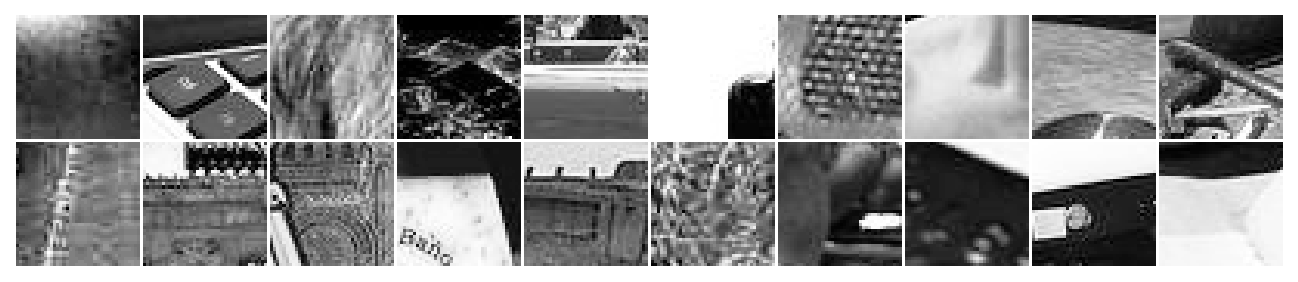

In [5]:
plot_weights(vld[inds]);

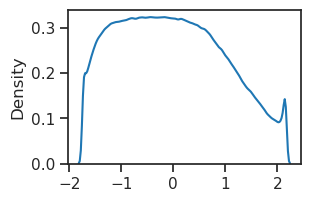

In [6]:
sns.kdeplot(vld.ravel())
plt.show()

### whitened

In [7]:
_, vld, _ = make_dataset('ImageNet40-wht', skip_trn=True, to_tensor_dataset=False)
vld = vld[0]
vld.shape

torch.Size([50000, 1, 40, 40])

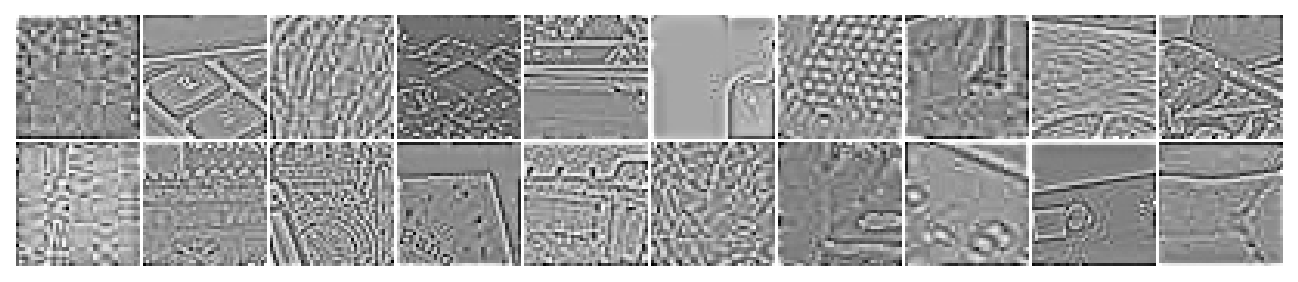

In [8]:
plot_weights(vld[inds]);

In [ ]:
sns.kdeplot(vld.ravel())
plt.show()

## Load, crop, process, save

In [6]:
"""
Process ImageNet ILSVRC2012 → 40×40 grayscale center crops.

Steps:
  1. Load each image, convert to grayscale
  2. Center-crop 40×40
  3. Collect into arrays
  4. Z-score using training-set statistics
  5. Save to /home/hadi/Datasets/ImageNet/crop40/

Output shape: (N, 1, 40, 40), float32
"""

from pathlib import Path
from PIL import Image


SRC_DIR = Path.home() / 'Datasets' / 'ImageNet' / 'ILSVRC2012'
DST_DIR = Path.home() / 'Datasets' / 'ImageNet' / 'crop40' / 'raw'
CROP_SIZE = 40


def center_crop_grey(img_path: str, crop_size: int = CROP_SIZE):
    """Load image, convert to greyscale, center-crop."""
    try:
        img = Image.open(img_path).convert('L')
    except Exception as e:
        return None

    w, h = img.size
    if w < crop_size or h < crop_size:
        return None

    left = (w - crop_size) // 2
    top = (h - crop_size) // 2
    img = img.crop((left, top, left + crop_size, top + crop_size))

    # (crop_size, crop_size), uint8
    return np.array(img, dtype=np.float32)


def collect_split(split_dir: Path, desc: str = ''):
    """Walk class folders, crop each image, return (N, 40, 40) float32."""
    arrays = []
    # gather all image paths first for a proper progress bar
    paths = []
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_file in sorted(class_dir.iterdir()):
            suffix = img_file.suffix.lower()
            if suffix in ('.jpeg', '.jpg', '.png', '.webp', '.JPEG'):
                paths.append(img_file)

    print(f"[{desc}] Found {len(paths)} images")
    skipped = 0
    for p in tqdm(paths, desc=desc):
        patch = center_crop_grey(str(p))
        if patch is None:
            skipped += 1
            continue
        arrays.append(patch)

    if skipped:
        print(f"  skipped {skipped} images (too small or corrupt)")

    # (N, 40, 40)
    return np.stack(arrays, axis=0)


def main():
    # --- collect raw crops ---
    trn_dir = SRC_DIR / 'train'
    val_dir = SRC_DIR / 'validation'

    assert trn_dir.is_dir(), f"not found: {trn_dir}"
    assert val_dir.is_dir(), f"not found: {val_dir}"

    x_trn = collect_split(trn_dir, desc='train')
    x_vld = collect_split(val_dir, desc='validation')

    print(f"raw train: {x_trn.shape}, validation: {x_vld.shape}")

    # --- z-score normalization (stats from train only) ---
    mu = x_trn.mean()
    sd = x_trn.std()
    print(f"train pixel stats: mean={mu:.4f}, std={sd:.4f}")

    x_trn = (x_trn - mu) / sd
    x_vld = (x_vld - mu) / sd

    # --- reshape to (N, 1, 40, 40) ---
    x_trn = x_trn[:, None, :, :]
    x_vld = x_vld[:, None, :, :]

    print(f"final train: {x_trn.shape}, validation: {x_vld.shape}")
    print(f"train range: [{x_trn.min():.3f}, {x_trn.max():.3f}]")
    print(f"validation   range: [{x_vld.min():.3f}, {x_vld.max():.3f}]")

    # --- save ---
    DST_DIR.mkdir(parents=True, exist_ok=True)
    np.save(DST_DIR / 'x_trn.npy', x_trn)
    np.save(DST_DIR / 'x_vld.npy', x_vld)

    # also save normalization stats for reproducibility
    np.savez(DST_DIR / 'norm_stats.npz', mean=mu, std=sd)

    print(f"saved to {DST_DIR}")

In [7]:
%%time

main()

Found 1281167 images

train:   0%|          | 0/1281167 [00:00<?, ?it/s]

skipped 173 images (too small or corrupt)

Found 50000 images

validation:   0%|          | 0/50000 [00:00<?, ?it/s]

...

final train: (1280994, 1, 40, 40), val: (50000, 1, 40, 40)

train range: [-1.740, 2.163]

validation   range: [-1.740, 2.163]

saved to /home/hadi/Datasets/ImageNet/crop40

CPU times: user 57min 56s, sys: 1min 54s, total: 59min 51s
Wall time: 1h 3min


## Apply whitening

In [4]:
"""
Apply whitening + local contrast normalization + z-score
to the raw ImageNet 40×40 crops.

Reads from:  ~/Datasets/ImageNet/crop40/raw/
Writes to:   ~/Datasets/ImageNet/crop40/wht/

Uses do_process() from mcfe.utils.imgproc, which applies:
  1. Olshausen & Field whitening filter
  2. Jarrett et al. local contrast normalization
  3. Per-image spatial z-score
"""

from pathlib import Path
from mcfe.utils.imgproc import do_process

BASE = Path.home() / 'Datasets' / 'ImageNet' / 'crop40'
RAW_DIR = BASE / 'raw'
WHT_DIR = BASE / 'wht'

# batch size for processing (adjust based on GPU memory)
BATCH_SIZE = 2000


def process_split(x_raw: np.ndarray, name: str) -> np.ndarray:
    """Apply whitening pipeline in batches, return (N, 1, 40, 40) float32."""
    x = torch.from_numpy(x_raw).float().to(device)
    n = x.shape[0]
    results = []

    for i in tqdm(range(0, n, BATCH_SIZE)):
        batch = x[i:i + BATCH_SIZE]
        # do_process returns (whitened, wht+lcn, wht+lcn+zscore)
        # crop_size=0: keep 40×40, no border cropping
        _, _, x_wht = do_process(
            stim=batch,
            device=device,
            crop_size=0,
            kws_whiten=dict(f_0=0.5, n=4, batched=True),
            kws_contrast=dict(kernel_size=9, sigma=0.5, batched=True),
        )
        results.append(x_wht.cpu())
        # print(f"  {name}: {min(i + BATCH_SIZE, n)}/{n}")

    out = torch.cat(results).numpy()
    return out


def apply_whitening():
    WHT_DIR.mkdir(parents=True, exist_ok=True)

    for name in ['x_trn', 'x_vld']:
        path_in = RAW_DIR / f'{name}.npy'
        path_out = WHT_DIR / f'{name}.npy'

        print(f"loading {path_in}")
        x_raw = np.load(path_in)
        print(f"  shape: {x_raw.shape}, range: [{x_raw.min():.3f}, {x_raw.max():.3f}]")

        x_wht = process_split(x_raw, name)
        print(f"  processed range: [{x_wht.min():.3f}, {x_wht.max():.3f}]")

        np.save(path_out, x_wht)
        print(f"  saved {path_out}\n")

    print("done")

In [ ]:
apply_whitening()